# EDA General del Dataset Hidrometeorológico de Sinaloa

Este notebook presenta el análisis exploratorio de datos (EDA) general del dataset hidrometeorológico organizado del estado de Sinaloa, estructurado por estación, año y variable. El objetivo es caracterizar su estructura, cobertura temporal, disponibilidad de variables, calidad general de los datos, distribución estadística y posibles inconsistencias iniciales, con el fin de sustentar las etapas posteriores de análisis de valores faltantes, análisis temporal-estacional, limpieza y modelado de imputación.

## Importación de librerías

In [43]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 200)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Configuración de rutas

Se define la ruta raíz del proyecto y la ubicación del dataset organizado en la capa `interim`.

> **Ajusta `PROJECT_ROOT` a la ubicación de tu proyecto antes de ejecutar.**

In [2]:
PROJECT_ROOT = Path(r"/home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main")
DATA_DIR   = PROJECT_ROOT / "data" / "interim" / "organized" / "estado=sin"
INDEX_PATH = DATA_DIR / "_index.csv"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("INDEX_PATH   :", INDEX_PATH)
print("Existe DATA_DIR  :", DATA_DIR.exists())
print("Existe INDEX_PATH:", INDEX_PATH.exists())

PROJECT_ROOT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main
DATA_DIR     : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/data/interim/organized/estado=sin
INDEX_PATH   : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/data/interim/organized/estado=sin/_index.csv
Existe DATA_DIR  : True
Existe INDEX_PATH: True


## Carga del índice global

El archivo `_index.csv` funciona como inventario central del dataset organizado.

In [3]:
index_df = pd.read_csv(INDEX_PATH)

def normalize_path(raw_path: str, root: Path) -> Path:
    p = Path(raw_path)
    if p.exists():
        return p
    parts = p.parts
    try:
        data_idx = next(i for i, part in enumerate(parts) if part == "data")
        return root / Path(*parts[data_idx:])
    except StopIteration:
        return p

index_df["path_parquet"] = index_df["path_parquet"].apply(lambda x: normalize_path(x, PROJECT_ROOT))
index_df["path_csv"]     = index_df["path_csv"].apply(lambda x: normalize_path(x, PROJECT_ROOT))
index_df = index_df.drop_duplicates(subset=["station", "year", "variable"]).reset_index(drop=True)

print(f"Particiones en el índice: {len(index_df)}")
index_df.head()

Particiones en el índice: 19256


,station,year,variable,path_parquet,path_csv,rows,missing_pct
0,25074,1969,precip,/home/sebastian/Documentos/Tec/Proyecto_Reside...,/home/sebastian/Documentos/Tec/Proyecto_Reside...,365,0.000
1,25074,1969,evap,/home/sebastian/Documentos/Tec/Proyecto_Reside...,/home/sebastian/Documentos/Tec/Proyecto_Reside...,365,100.000
2,25074,1969,tmax,/home/sebastian/Documentos/Tec/Proyecto_Reside...,/home/sebastian/Documentos/Tec/Proyecto_Reside...,365,3.288
3,25074,1969,tmin,/home/sebastian/Documentos/Tec/Proyecto_Reside...,/home/sebastian/Documentos/Tec/Proyecto_Reside...,365,3.288
4,25074,1970,precip,/home/sebastian/Documentos/Tec/Proyecto_Reside...,/home/sebastian/Documentos/Tec/Proyecto_Reside...,365,0.000


## Validación inicial del índice

In [4]:
index_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19256 entries, 0 to 19255
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station       19256 non-null  int64  
 1   year          19256 non-null  int64  
 2   variable      19256 non-null  object 
 3   path_parquet  19256 non-null  object 
 4   path_csv      19256 non-null  object 
 5   rows          19256 non-null  int64  
 6   missing_pct   19256 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 1.0+ MB


## Descripción estructural del dataset

In [5]:
summary_struct = pd.DataFrame({
    "metrica": [
        "total_particiones", "total_estaciones", "total_años",
        "total_variables", "año_minimo", "año_maximo"
    ],
    "valor": [
        len(index_df), index_df["station"].nunique(), index_df["year"].nunique(),
        index_df["variable"].nunique(), index_df["year"].min(), index_df["year"].max()
    ]
})
summary_struct

,metrica,valor
0,total_particiones,19256
1,total_estaciones,168
2,total_años,110
3,total_variables,4
4,año_minimo,1908
5,año_maximo,2026


In [6]:
variables_disponibles = pd.DataFrame({"variables": sorted(index_df["variable"].unique())})
variables_disponibles

,variables
0,evap
1,precip
2,tmax
3,tmin


### Interpretación

El dataset organizado contiene **19,256 particiones** distribuidas entre **168 estaciones**, **110 años** (1908–2026) y **4 variables climáticas** (precip, evap, tmax, tmin). Esta organización modular por estación/año/variable facilita el acceso selectivo, la trazabilidad individual de cada archivo y la integración con el pipeline de imputación.

De las 192 estaciones descargadas originalmente, 168 cuentan con datos válidos en el índice. Las 24 restantes no generaron particiones, lo que puede deberse a archivos vacíos, ausencia de encabezado `FECHA` o registros sin fechas válidas.


## Cobertura por variable

In [7]:
coverage_var = index_df.groupby("variable").agg(
    archivos=("variable", "count"),
    estaciones=("station", "nunique"),
    años=("year", "nunique"),
    filas_totales=("rows", "sum"),
    faltantes_promedio_pct=("missing_pct", "mean")
).reset_index().sort_values("variable")
coverage_var

,variable,archivos,estaciones,años,filas_totales,faltantes_promedio_pct
0,evap,4814,168,110,1601384,39.459930
1,precip,4814,168,110,1601384,0.807213
2,tmax,4814,168,110,1601384,7.419859
3,tmin,4814,168,110,1601384,7.419859


## Cobertura temporal por estación

In [8]:
coverage_station = index_df.groupby("station").agg(
    year_min=("year", "min"),
    year_max=("year", "max"),
    total_years=("year", "nunique"),
    total_files=("variable", "count"),
    total_rows=("rows", "sum"),
    missing_pct_mean=("missing_pct", "mean")
).reset_index().sort_values("total_years", ascending=False)
coverage_station.head(20)

,station,year_min,year_max,total_years,total_files,total_rows,missing_pct_mean
43,25046,1942,2026,84,336,117036,2.218351
76,25081,1944,2026,83,332,115592,7.435864
34,25037,1953,2025,70,280,99836,0.602261
14,25015,1961,2026,66,264,95064,1.644852
42,25045,1961,2025,65,260,91016,4.028808
46,25049,1961,2025,65,260,91276,3.908665
0,25001,1961,2025,65,260,86092,1.144592
31,25033,1961,2025,65,260,90784,0.748231
101,25110,1960,2025,65,260,87092,14.293346
82,25087,1961,2025,65,260,90156,3.760623


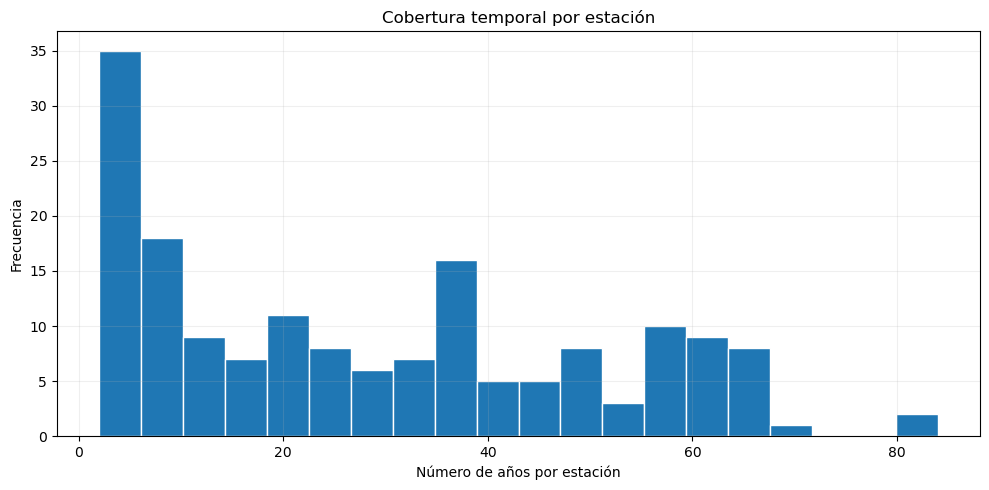

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(coverage_station["total_years"], bins=20, edgecolor="white")
plt.xlabel("Número de años por estación")
plt.ylabel("Frecuencia")
plt.title("Cobertura temporal por estación")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
print("Total de estaciones:", len(coverage_station))
print("\nDistribución de años:")
print(coverage_station["total_years"].describe())

Total de estaciones: 168

Distribución de años:
count    168.000000
mean      28.654762
std       21.407925
min        2.000000
25%        7.000000
50%       25.000000
75%       45.250000
max       84.000000
Name: total_years, dtype: float64


### Interpretación

La cobertura temporal por estación es marcadamente heterogénea. La estación con mayor cobertura acumula **84 años** de registro (25046, Jaina), mientras que la mediana es de **25 años** y el 25% inferior cuenta con menos de 7 años. Esto implica que la mayoría de las estaciones tienen historiales cortos o discontinuos.

Esta diferencia debe considerarse al seleccionar subconjuntos para modelado: las estaciones con series largas son preferibles como anclaje para el entrenamiento, mientras que las de cobertura corta representan el escenario de mayor desafío para la imputación.


## Completitud general y porcentaje de faltantes

In [11]:
index_df["missing_pct"].describe()

count    19256.000000
mean        13.776715
std         33.106643
min          0.000000
25%          0.000000
50%          0.000000
75%          0.549000
max        100.000000
Name: missing_pct, dtype: float64

In [12]:
missing_summary_var = index_df.groupby("variable")["missing_pct"].describe()
missing_summary_var

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
evap,4814.0,39.459930,47.121571,0.0,0.0,1.316,100.000,100.0
precip,4814.0,0.807213,5.675771,0.0,0.0,0.000,0.000,100.0
tmax,4814.0,7.419859,24.732387,0.0,0.0,0.000,0.273,100.0
tmin,4814.0,7.419859,24.732387,0.0,0.0,0.000,0.273,100.0


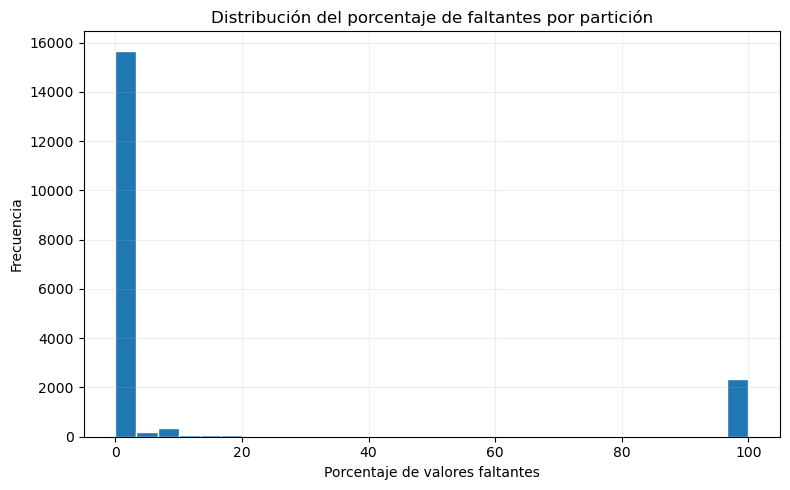

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(index_df["missing_pct"].dropna(), bins=30, edgecolor="white")
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("Frecuencia")
plt.title("Distribución del porcentaje de faltantes por partición")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretación

El porcentaje global de faltantes presenta una distribución fuertemente sesgada: la mediana es **0%** y el percentil 75 es apenas 0.55%, lo que indica que la mayoría de las particiones están completas. Sin embargo, el promedio es **13.78%** y el máximo es **100%**, evidenciando que un subconjunto de particiones arrastra casi todo el peso de los faltantes.

Por variable, la disparidad es notable:

| Variable | Faltantes promedio |
|----------|--------------------|
| `precip`  | 0.8% |
| `tmax`    | 7.4% |
| `tmin`    | 7.4% |
| `evap`    | **39.5%** |

`evap` es la variable más problemática: casi 4 de cada 10 registros son nulos en promedio. Además, `tmax` y `tmin` presentan exactamente el mismo porcentaje de faltantes, lo que sugiere que se registran de manera conjunta y fallan al mismo tiempo. Esta covarianza en los faltantes es relevante para la estrategia de imputación multivariante.


## Inspección de las particiones con mayor y menor faltante

In [14]:
top_missing = index_df.sort_values("missing_pct", ascending=False).head(15)
top_missing[["station", "year", "variable", "rows", "missing_pct"]]

,station,year,variable,rows,missing_pct
1,25074,1969,evap,365,100.0
9,25074,1971,evap,365,100.0
13,25074,1972,evap,366,100.0
3625,25047,1981,evap,365,100.0
3653,25047,1988,evap,213,100.0
3649,25047,1987,evap,365,100.0
3645,25047,1986,evap,365,100.0
3641,25047,1985,evap,365,100.0
3669,25036,1964,evap,366,100.0
3665,25036,1963,evap,365,100.0


In [15]:
top_complete = index_df.sort_values("missing_pct", ascending=True).head(15)
top_complete[["station", "year", "variable", "rows", "missing_pct"]]

,station,year,variable,rows,missing_pct
9940,25045,1981,precip,365,0.0
9925,25045,1977,evap,365,0.0
9924,25045,1977,precip,365,0.0
9923,25045,1976,tmin,366,0.0
9922,25045,1976,tmax,366,0.0
9921,25045,1976,evap,366,0.0
9952,25045,1984,precip,366,0.0
9948,25045,1983,precip,365,0.0
9947,25045,1982,tmin,365,0.0
9946,25045,1982,tmax,365,0.0


## Carga de una muestra consolidada

`date` se convierte a datetime y `value` a numérico aquí, una sola vez, para que todas las celdas posteriores funcionen correctamente.

In [16]:
sample_index = index_df.copy()
print(f"Cargando todos los archivos: {len(sample_index)}")

Cargando todos los archivos: 19256


In [17]:
dfs = []
skipped = 0

for _, row in sample_index.iterrows():
    parquet_path = Path(row["path_parquet"])
    if not parquet_path.exists():
        skipped += 1
        continue
    try:
        df_part = pd.read_parquet(parquet_path)
        df_part["station"]  = row["station"]
        df_part["year"]     = row["year"]
        df_part["variable"] = row["variable"]
        dfs.append(df_part)
    except Exception as e:
        skipped += 1
        print(f"  [WARN] No se pudo leer {parquet_path.name}: {e}")

if dfs:
    eda_df = pd.concat(dfs, ignore_index=True)
    eda_df["date"]  = pd.to_datetime(eda_df["date"], errors="coerce")
    eda_df["value"] = pd.to_numeric(eda_df["value"], errors="coerce")
else:
    eda_df = pd.DataFrame(columns=["date", "value", "station", "year", "variable"])

print(f"Filas cargadas   : {len(eda_df):,}")
print(f"Archivos omitidos: {skipped}")
eda_df.head()

Filas cargadas   : 6,405,536
Archivos omitidos: 0


,date,value,station,year,variable
0,1969-01-01,0.0,25074,1969,precip
1,1969-01-02,0.0,25074,1969,precip
2,1969-01-03,0.0,25074,1969,precip
3,1969-01-04,0.0,25074,1969,precip
4,1969-01-05,0.0,25074,1969,precip


## Validación de la muestra consolidada

In [18]:
print("Filas consolidadas :", len(eda_df))
print("Estaciones en muestra:", eda_df["station"].nunique())
print("Años en muestra      :", eda_df["year"].nunique())
print("Variables en muestra :", sorted(eda_df["variable"].dropna().unique()))

Filas consolidadas : 6405536
Estaciones en muestra: 168
Años en muestra      : 110
Variables en muestra : ['evap', 'precip', 'tmax', 'tmin']


In [19]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405536 entries, 0 to 6405535
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[ns]
 1   value     float64       
 2   station   int64         
 3   year      int64         
 4   variable  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 244.4+ MB


## Calidad básica de datos

In [20]:
quality_summary = pd.DataFrame({
    "metrica": ["filas_totales", "fechas_nulas", "values_nulos", "duplicados_totales"],
    "valor":   [
        len(eda_df),
        int(eda_df["date"].isna().sum()),
        int(eda_df["value"].isna().sum()),
        int(eda_df.duplicated().sum())
    ]
})
quality_summary

,metrica,valor
0,filas_totales,6405536
1,fechas_nulas,0
2,values_nulos,850639
3,duplicados_totales,0


### Interpretación

El DataFrame consolidado contiene **6,405,536 filas** sin fechas nulas ni duplicados, lo que confirma la integridad estructural del dataset. Los **850,639 valores nulos** (13.3% global) corresponden exclusivamente a la columna `value` y se concentran principalmente en `evap`, consistente con lo observado en el análisis de faltantes por variable.

La ausencia de duplicados valida que la partición por estación/año/variable aplicada en la etapa de estructuración eliminó correctamente registros redundantes.


---
# CRITERIO 1 — Análisis descriptivo de variables numéricas y categóricas

## Estadística descriptiva completa por variable numérica

Se calculan media, mediana, moda, desviación estándar y percentiles p5, p10, p25, p75, p90 y p95 para cada variable climática.

In [21]:
variables_en_muestra = sorted(eda_df["variable"].dropna().unique())

def descriptive_stats(df: pd.DataFrame, variable: str) -> dict:
    x = df.loc[df["variable"] == variable, "value"].dropna()
    if len(x) == 0:
        return {"variable": variable}
    moda_vals = x.mode()
    moda = round(float(moda_vals.iloc[0]), 4) if len(moda_vals) > 0 else None
    return {
        "variable" : variable,
        "n"        : len(x),
        "media"    : round(x.mean(),            4),
        "mediana"  : round(x.median(),          4),
        "moda"     : moda,
        "std"      : round(x.std(),             4),
        "min"      : round(x.min(),             4),
        "p5"       : round(x.quantile(0.05),    4),
        "p10"      : round(x.quantile(0.10),    4),
        "p25"      : round(x.quantile(0.25),    4),
        "p75"      : round(x.quantile(0.75),    4),
        "p90"      : round(x.quantile(0.90),    4),
        "p95"      : round(x.quantile(0.95),    4),
        "max"      : round(x.max(),             4),
    }

stats_completas = pd.DataFrame([
    descriptive_stats(eda_df, var) for var in variables_en_muestra
])
stats_completas

,variable,n,media,mediana,moda,std,min,p5,p10,p25,p75,p90,p95,max
0,evap,987744,5.2799,4.95,4.0,2.5514,0.01,1.69,2.23,3.38,6.9,8.83,9.94,24.95
1,precip,1590561,1.9597,0.00,0.0,8.8057,0.00,0.00,0.00,0.00,0.0,2.50,12.00,390.50
2,tmax,1488296,32.6540,33.00,35.0,4.8975,5.00,24.00,26.00,29.90,36.0,38.50,40.00,55.00
3,tmin,1488296,16.7114,16.50,24.0,6.2076,-10.00,7.00,8.50,12.00,22.5,24.50,25.50,37.00


### Interpretación

Las estadísticas descriptivas revelan comportamientos diferenciados por variable:

- **PRECIP**: media de 1.96 mm con mediana de 0.0 mm, lo que confirma una distribución fuertemente asimétrica hacia la derecha: la mayoría de los días no llueve. El máximo registrado es de 390.5 mm en un solo día, consistente con eventos ciclónicos.
- **EVAP**: media de 5.28 mm/día con valores entre 0.01 y 24.95 mm. La distribución es más simétrica, con p90 en 8.83 mm.
- **TMAX**: media de 32.65°C con rango operativo entre p5=24°C y p95=40°C, reflejando el clima cálido predominante en Sinaloa. El valor máximo registrado (55°C) es sospechoso y probablemente un error de registro.
- **TMIN**: media de 16.71°C con rango entre p5=7°C y p95=25.5°C. El valor mínimo de -10°C merece revisión contextual dado el perfil climático de la región.

La moda de TMIN es 24°C, valor cercano al límite superior habitual, lo que puede reflejar sesgo en la distribución o concentración de registros en estaciones costeras cálidas.


## Análisis de variables categóricas — Frecuencias

Se analiza la distribución de las variables categóricas del dataset: variable climática, estación y año.

In [22]:
# Frecuencia por variable climática
freq_variable = (
    eda_df["variable"].value_counts()
    .reset_index()
)
freq_variable.columns = ["variable", "frecuencia"]
freq_variable["porcentaje"] = (freq_variable["frecuencia"] / freq_variable["frecuencia"].sum() * 100).round(2)
print("Frecuencia por variable climática:")
print(freq_variable.to_string(index=False))

Frecuencia por variable climática:
variable  frecuencia  porcentaje
  precip     1601384        25.0
    evap     1601384        25.0
    tmax     1601384        25.0
    tmin     1601384        25.0


In [23]:
# Top 15 estaciones con más registros
freq_station = eda_df["station"].value_counts().head(15).reset_index()
freq_station.columns = ["station", "frecuencia"]
print("Top 15 estaciones con más registros en la muestra:")
print(freq_station.to_string(index=False))

Top 15 estaciones con más registros en la muestra:
 station  frecuencia
   25046      117036
   25081      115592
   25037       99836
   25015       95064
   25049       91276
   25045       91016
   25033       90784
   25087       90156
   25030       89936
   25078       88680
   25041       88388
   25116       87232
   25023       87128
   25110       87092
   25019       86160


In [24]:
# Frecuencia de registros por año
freq_year = eda_df["year"].value_counts().sort_index().reset_index()
freq_year.columns = ["year", "frecuencia"]
print("Frecuencia de registros por año (primeros 20):")
print(freq_year.head(20).to_string(index=False))

Frecuencia de registros por año (primeros 20):
 year  frecuencia
 1908         244
 1909        1336
 1910        1460
 1911        1240
 1912        1464
 1913         848
 1921         724
 1922         600
 1924         368
 1925         736
 1926        2428
 1927        2920
 1928        3412
 1929        3280
 1930        3168
 1931        3276
 1932        2072
 1933        1484
 1934        1460
 1935        1460


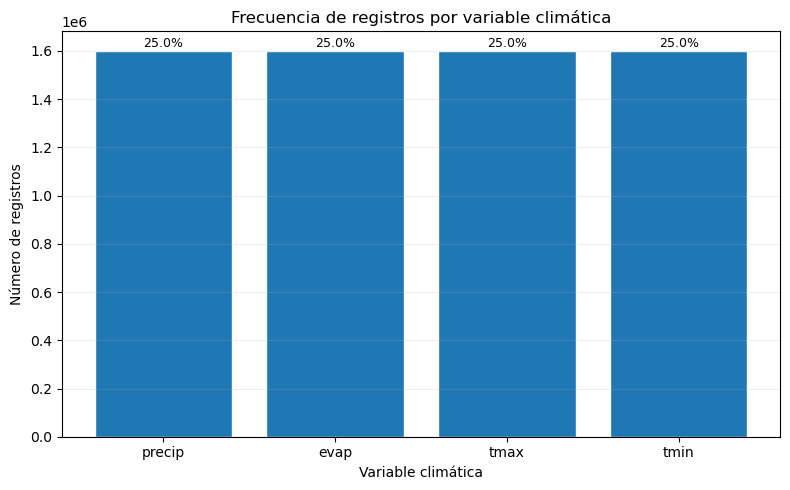

In [25]:
# Gráfico: frecuencia por variable climática
plt.figure(figsize=(8, 5))
bars = plt.bar(freq_variable["variable"], freq_variable["frecuencia"], edgecolor="white")
for bar, pct in zip(bars, freq_variable["porcentaje"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + freq_variable["frecuencia"].max() * 0.01,
             f"{pct}%", ha="center", fontsize=9)
plt.xlabel("Variable climática")
plt.ylabel("Número de registros")
plt.title("Frecuencia de registros por variable climática")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

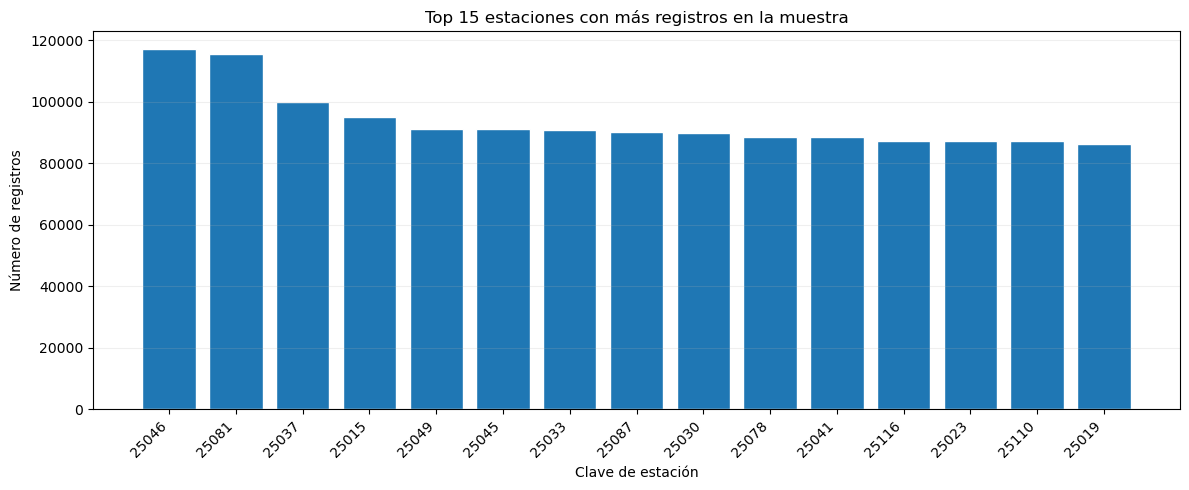

In [26]:
# Gráfico: top 15 estaciones
plt.figure(figsize=(12, 5))
plt.bar(freq_station["station"].astype(str), freq_station["frecuencia"], edgecolor="white")
plt.xlabel("Clave de estación")
plt.ylabel("Número de registros")
plt.title("Top 15 estaciones con más registros en la muestra")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

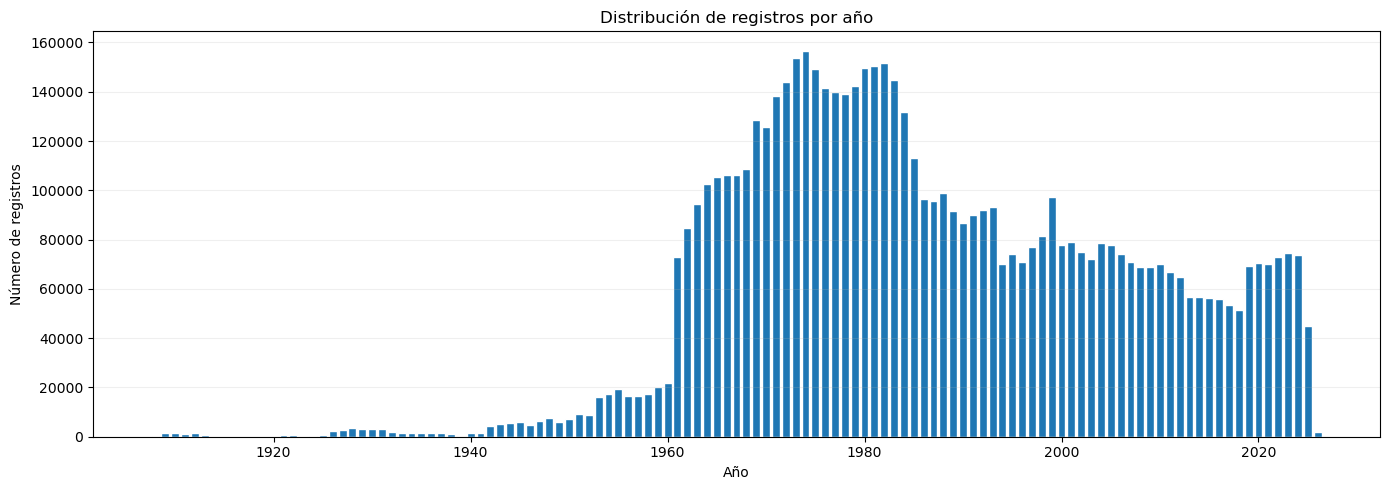

In [27]:
# Gráfico: registros por año
plt.figure(figsize=(14, 5))
plt.bar(freq_year["year"], freq_year["frecuencia"], edgecolor="white", width=0.8)
plt.xlabel("Año")
plt.ylabel("Número de registros")
plt.title("Distribución de registros por año")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretación

Las cuatro variables climáticas tienen exactamente la misma frecuencia de registros (1,601,384 cada una, 25% del total), lo que confirma que la estructuración por variable generó particiones simétricas.

La distribución por estación es desigual: la estación 25046 (Jaina) concentra 117,036 registros mientras la mediana ronda los 60,000, indicando heterogeneidad espacial significativa. Las 15 estaciones con mayor cobertura pertenecen mayoritariamente a municipios de Culiacán, El Fuerte y zonas serranas con larga historia de operación.

La distribución por año muestra escasa densidad antes de 1940 (menos de 5,000 registros anuales), crecimiento sostenido desde 1950 y mayor concentración en el periodo 1960–2010. Los años recientes (2020–2026) muestran menor densidad, coherente con el estado operativo de muchas estaciones suspendidas.


---
# CRITERIO 2 — Visualizaciones exploratorias

## Histogramas por variable

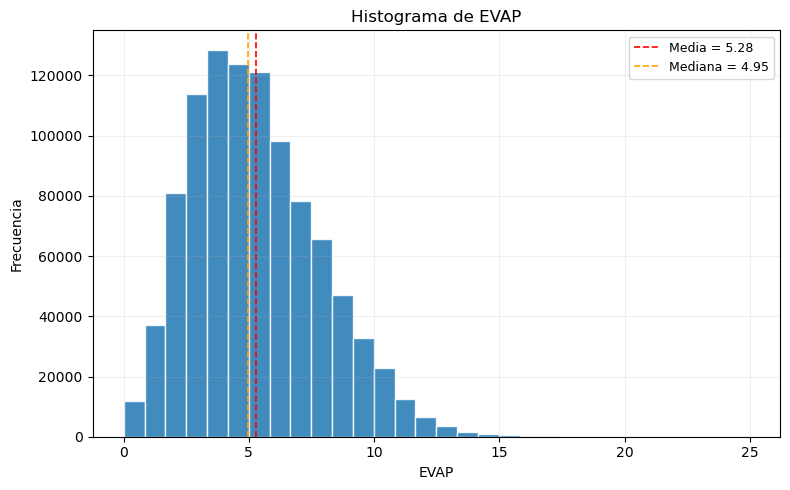

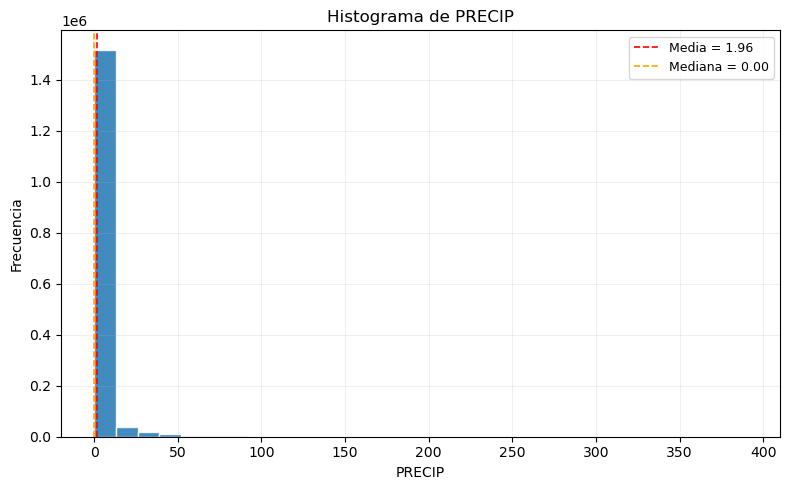

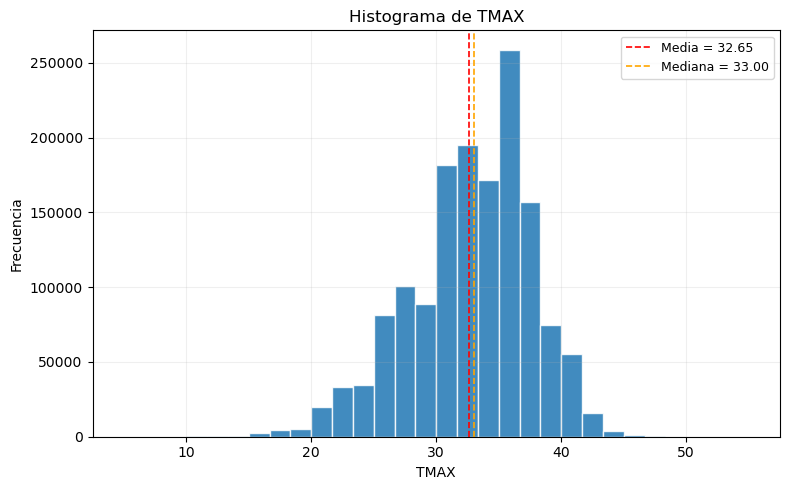

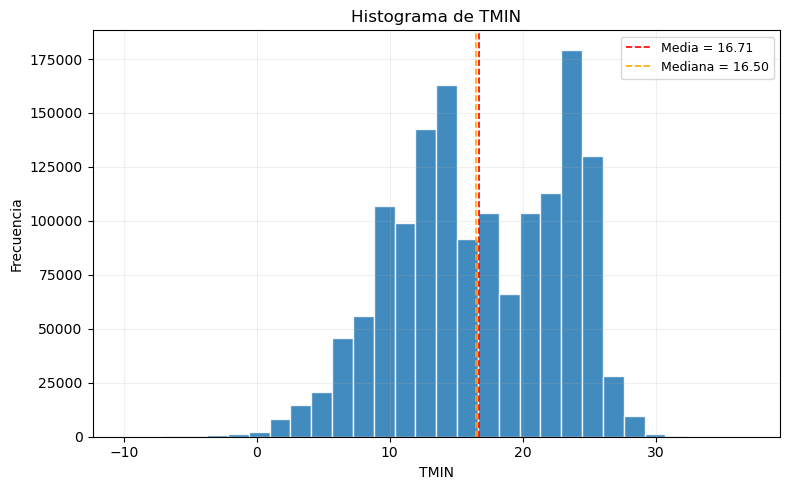

In [28]:
for var in variables_en_muestra:
    subset = eda_df.loc[eda_df["variable"] == var, "value"].dropna()
    if subset.empty:
        print(f"[SKIP] {var}: sin datos")
        continue
    plt.figure(figsize=(8, 5))
    plt.hist(subset, bins=30, edgecolor="white", alpha=0.85)
    plt.axvline(subset.mean(),   color="red",    linestyle="--", linewidth=1.2,
                label=f"Media = {subset.mean():.2f}")
    plt.axvline(subset.median(), color="orange", linestyle="--", linewidth=1.2,
                label=f"Mediana = {subset.median():.2f}")
    plt.xlabel(var.upper())
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {var.upper()}")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Interpretación

Los histogramas confirman los perfiles distribucionales esperados:

- **PRECIP**: distribución con cola derecha extrema. La gran mayoría de valores se concentran en cero, con una cola que llega hasta 390.5 mm. La media (1.96 mm) supera ampliamente a la mediana (0.0 mm), confirmando asimetría positiva severa.
- **EVAP**: distribución aproximadamente unimodal centrada entre 4 y 6 mm/día. La media y mediana son cercanas (5.28 vs 4.95), indicando distribución relativamente simétrica.
- **TMAX y TMIN**: distribuciones aproximadamente simétricas con forma acampanada. TMAX se centra alrededor de 33°C y TMIN alrededor de 16.5°C, reflejando el gradiente térmico diario típico del clima sinaloense.


## Boxplots por variable

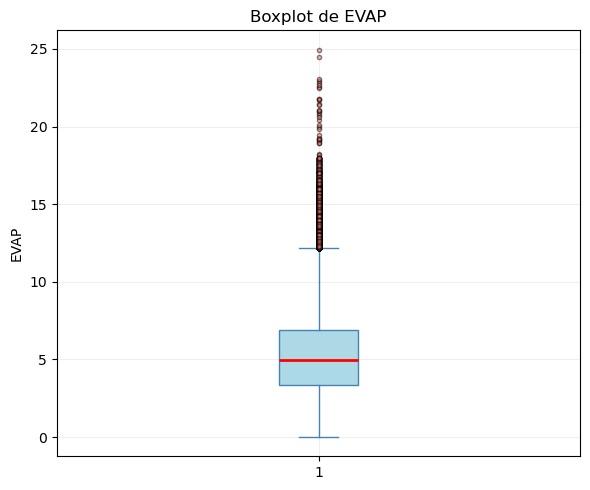

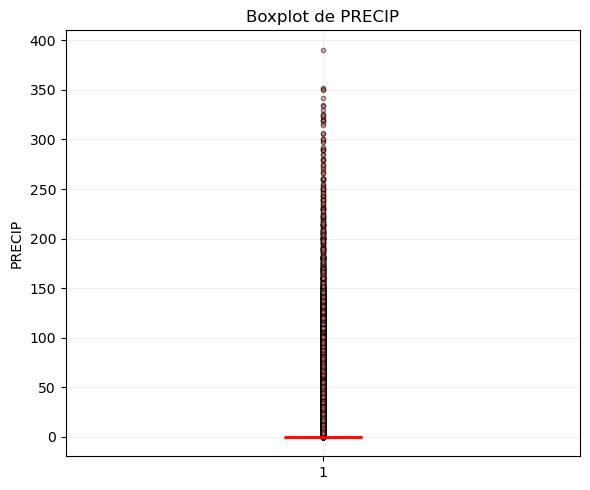

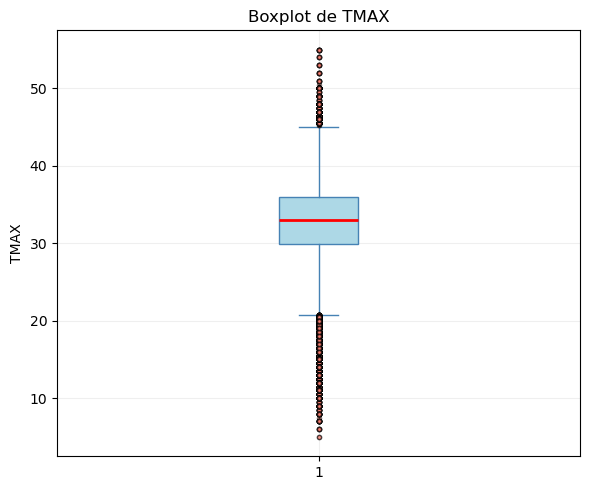

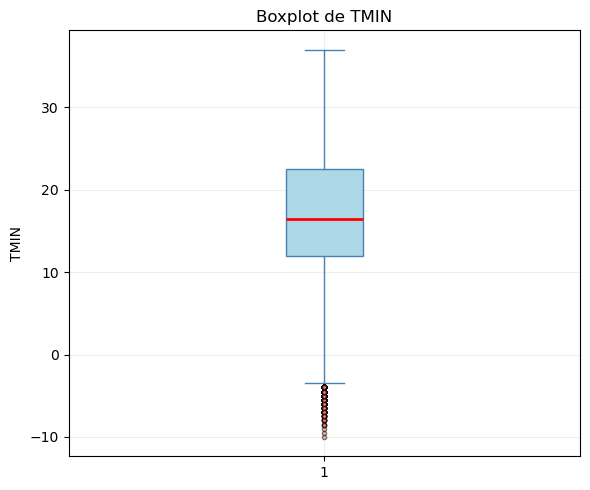

In [29]:
for var in variables_en_muestra:
    subset = eda_df.loc[eda_df["variable"] == var, "value"].dropna()
    if subset.empty:
        print(f"[SKIP] {var}: sin datos")
        continue
    plt.figure(figsize=(6, 5))
    plt.boxplot(
        subset, vert=True, patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="steelblue"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="steelblue"),
        capprops=dict(color="steelblue"),
        flierprops=dict(marker="o", markerfacecolor="salmon", markersize=3, alpha=0.5)
    )
    plt.ylabel(var.upper())
    plt.title(f"Boxplot de {var.upper()}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Interpretación

Los boxplots muestran la dispersión relativa y los valores extremos de cada variable:

- **PRECIP**: caja muy comprimida en cero con una cola de outliers extensa, consistente con su distribución. Cualquier valor positivo supera el umbral IQR×1.5 (límite superior = 0.0), lo que explica el alto número de outliers detectados.
- **EVAP**: caja de amplitud moderada (IQR = 3.52 mm) con outliers en el extremo alto por encima de 12.18 mm/día.
- **TMAX**: caja amplia (IQR = 6.1°C) con outliers tanto en extremos altos (>45°C, posibles errores) como bajos (<20.75°C, días atípicamente fríos o errores).
- **TMIN**: caja la más amplia del grupo (IQR = 10.5°C), con pocos outliers en el extremo bajo (<-3.75°C).


## Conteo de registros por variable

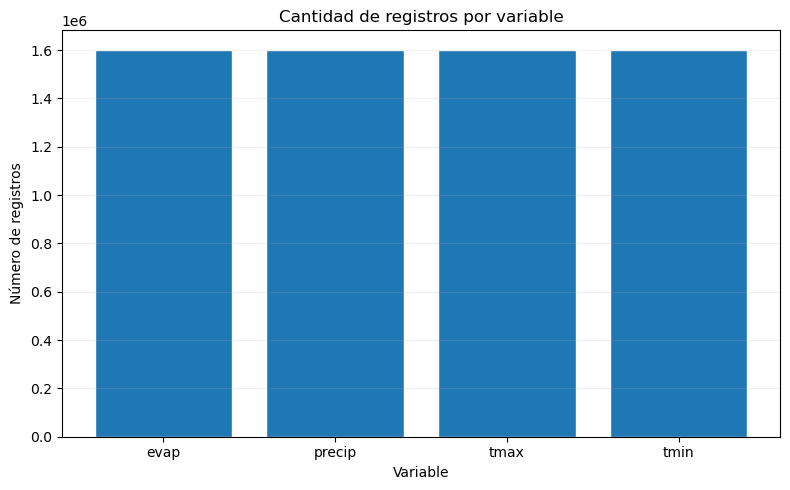

In [30]:
count_var = eda_df.groupby("variable").size().reset_index(name="n_registros").sort_values("variable")

plt.figure(figsize=(8, 5))
plt.bar(count_var["variable"], count_var["n_registros"], edgecolor="white")
plt.xlabel("Variable")
plt.ylabel("Número de registros")
plt.title("Cantidad de registros por variable")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Diagramas de dispersión entre variables

Se exploran las relaciones entre pares de variables climáticas pivotando la muestra a formato wide.

In [31]:
eda_wide = eda_df.pivot_table(
    index=["station", "date"],
    columns="variable",
    values="value"
).reset_index()
eda_wide.columns.name = None

print(f"Filas en formato wide: {len(eda_wide)}")
print(f"Columnas disponibles : {list(eda_wide.columns)}")
eda_wide.head()

Filas en formato wide: 1599488
Columnas disponibles : ['station', 'date', 'evap', 'precip', 'tmax', 'tmin']


,station,date,evap,precip,tmax,tmin
0,25001,1961-01-01,NaN,0.0,25.0,13.0
1,25001,1961-01-02,NaN,0.0,27.5,14.0
2,25001,1961-01-03,NaN,0.0,31.0,11.0
3,25001,1961-01-04,NaN,0.0,32.0,13.0
4,25001,1961-01-05,NaN,0.0,29.0,14.0


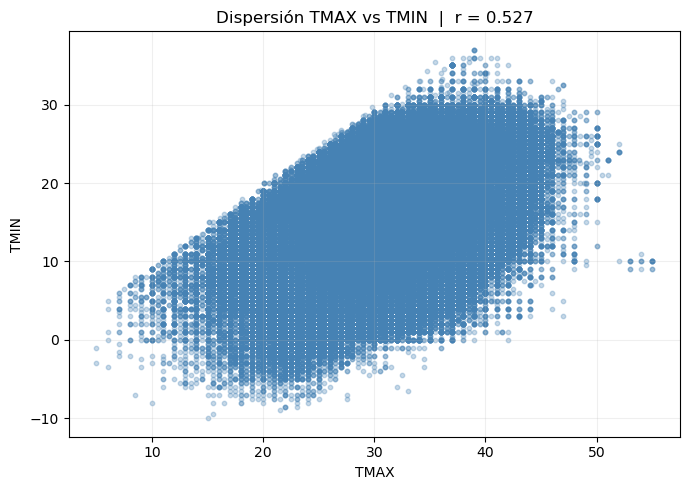

  Correlación de Pearson (TMAX vs TMIN): 0.5270


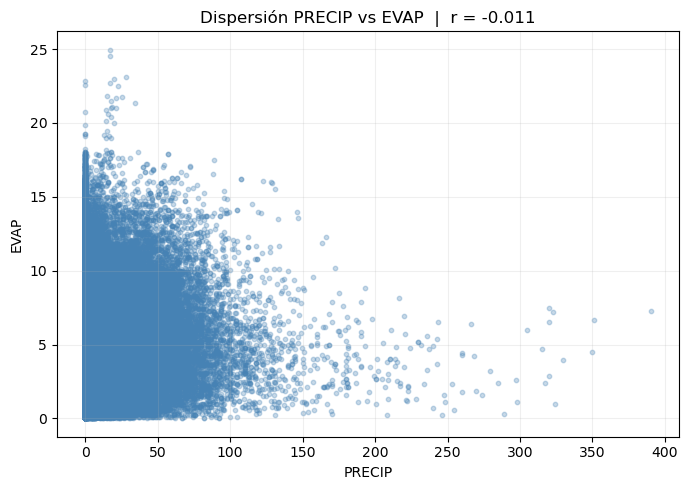

  Correlación de Pearson (PRECIP vs EVAP): -0.0112


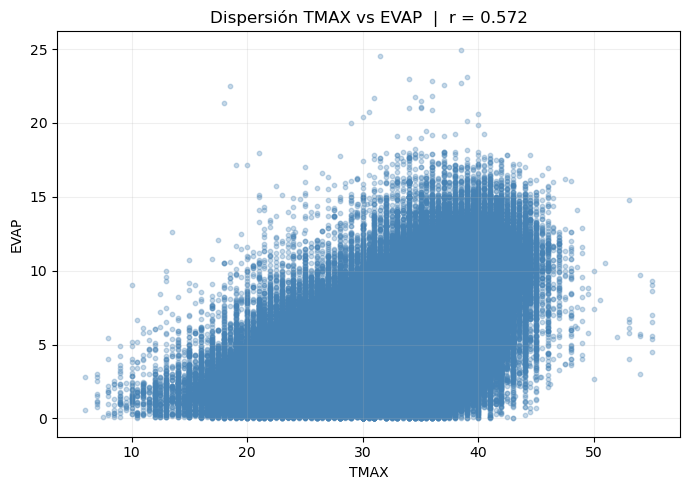

  Correlación de Pearson (TMAX vs EVAP): 0.5715


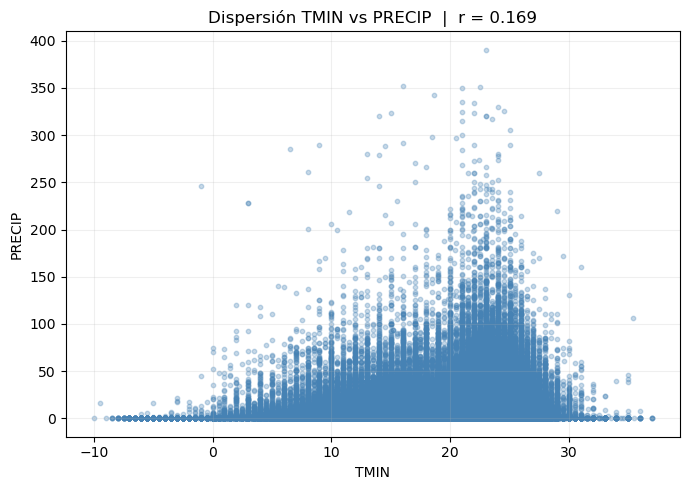

  Correlación de Pearson (TMIN vs PRECIP): 0.1688


In [32]:
scatter_pairs = [
    ("tmax", "tmin"),
    ("precip", "evap"),
    ("tmax", "evap"),
    ("tmin", "precip"),
]

cols_disponibles = [str(c).lower() for c in eda_wide.columns]

for x_var, y_var in scatter_pairs:
    if x_var not in cols_disponibles or y_var not in cols_disponibles:
        print(f"[SKIP] Par ({x_var}, {y_var}): alguna variable no está en la muestra")
        continue

    pair_df = eda_wide[[x_var, y_var]].dropna()
    if len(pair_df) < 10:
        print(f"[SKIP] Par ({x_var}, {y_var}): datos insuficientes")
        continue

    corr = pair_df[x_var].corr(pair_df[y_var])

    plt.figure(figsize=(7, 5))
    plt.scatter(pair_df[x_var], pair_df[y_var], alpha=0.3, s=10, color="steelblue")
    plt.xlabel(x_var.upper())
    plt.ylabel(y_var.upper())
    plt.title(f"Dispersión {x_var.upper()} vs {y_var.upper()}  |  r = {corr:.3f}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    print(f"  Correlación de Pearson ({x_var.upper()} vs {y_var.upper()}): {corr:.4f}")

### Interpretación

Los coeficientes de correlación de Pearson obtenidos revelan relaciones estadísticamente coherentes:

| Par | r de Pearson | Interpretación |
|-----|-------------|----------------|
| TMAX vs TMIN | **0.527** | Correlación positiva moderada. Días más calurosos tienden a tener noches más cálidas. |
| TMAX vs EVAP | **0.572** | Correlación positiva moderada. Mayor temperatura impulsa la evaporación. |
| TMIN vs PRECIP | **0.169** | Correlación débil. Días lluviosos tienden a ser marginalmente más cálidos en la mínima. |
| PRECIP vs EVAP | **-0.011** | Sin correlación lineal apreciable. La evaporación no responde linealmente a la lluvia diaria. |

La correlación moderada (no alta) entre TMAX y TMIN (r=0.527) es relevante para el modelado: aunque comparten tendencia general, no son redundantes. Esto justifica tratarlas como variables independientes en la imputación, aunque su fallo simultáneo en los registros sugiere usarlas como covariables mutuas.


## Series temporales de ejemplo

In [35]:
example_pairs = (
    eda_df.groupby(["station", "variable"])
    .filter(lambda g: g["value"].notna().sum() > 30)
    [["station", "variable"]]
    .drop_duplicates()
    .head(4)
    .values.tolist()
)
print("Pares seleccionados:", example_pairs)

Pares seleccionados: [[25074, 'precip'], [25074, 'evap'], [25074, 'tmax'], [25074, 'tmin']]


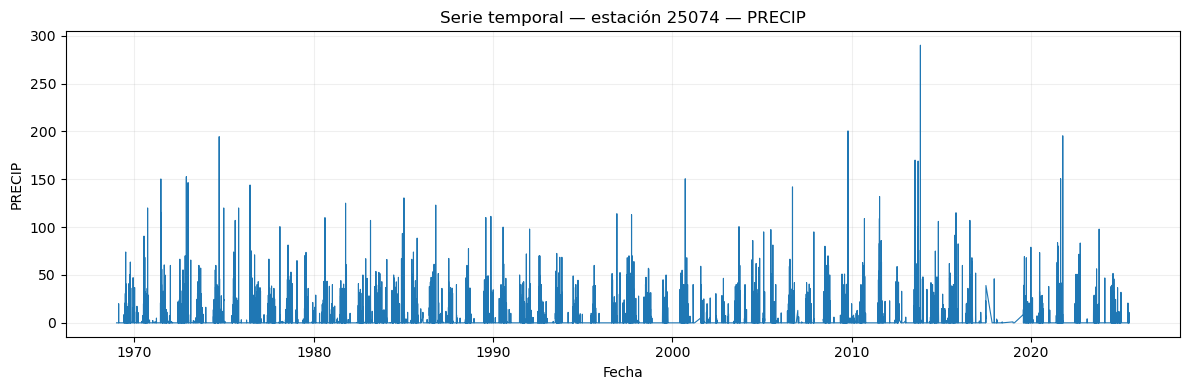

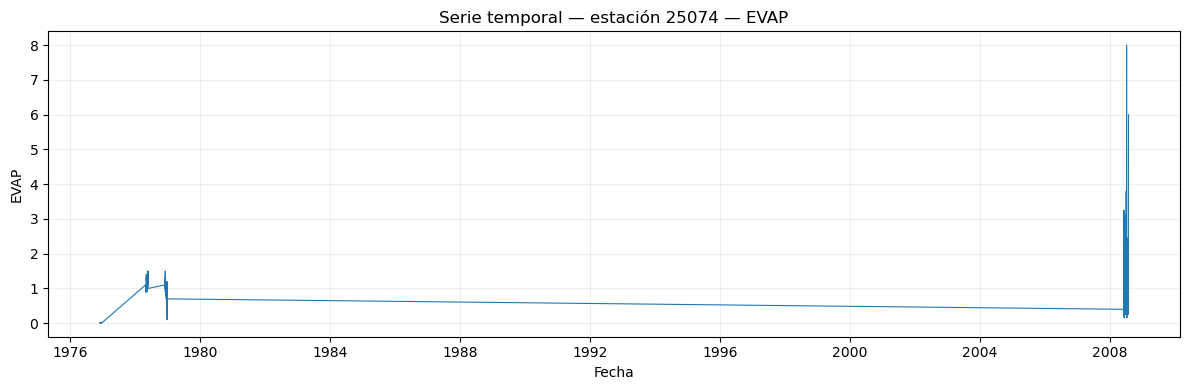

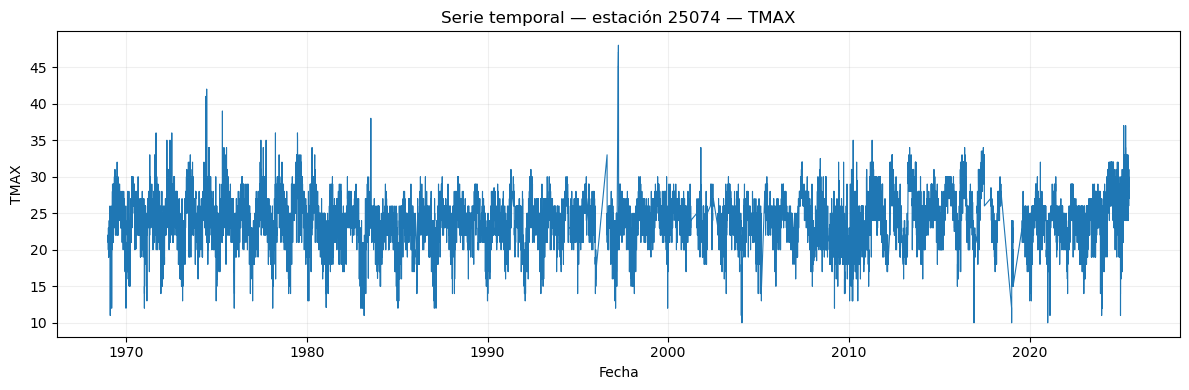

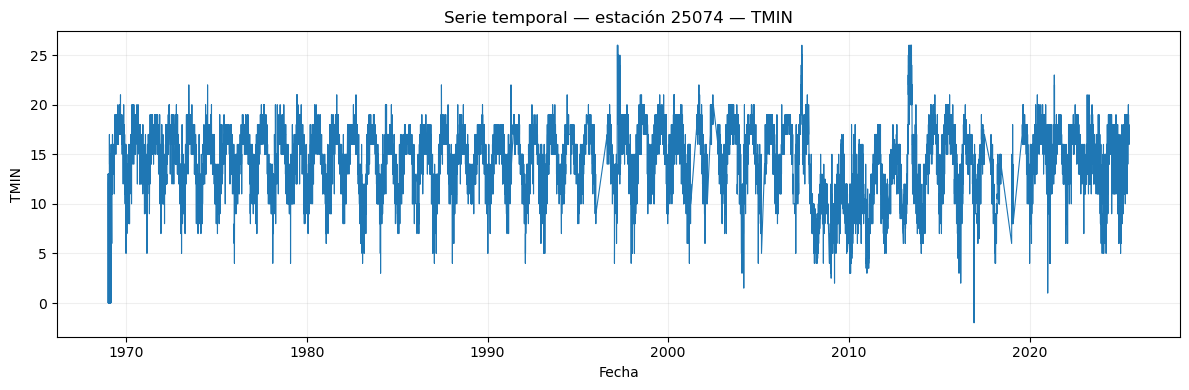

In [36]:
for station, variable in example_pairs:
    subset = (
        eda_df[(eda_df["station"] == station) & (eda_df["variable"] == variable)]
        .dropna(subset=["date", "value"])
        .sort_values("date")
    )
    if subset.empty:
        print(f"[SKIP] Estación {station} / {variable}: sin datos")
        continue
    plt.figure(figsize=(12, 4))
    plt.plot(subset["date"], subset["value"], linewidth=0.8)
    plt.xlabel("Fecha")
    plt.ylabel(variable.upper())
    plt.title(f"Serie temporal — estación {station} — {variable.upper()}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Interpretación

Las series temporales de ejemplo permiten observar visualmente la continuidad del registro, la variabilidad estacional y la distribución de huecos. En las series mostradas se aprecian:

- Patrones estacionales claros en TMAX y TMIN, con oscilaciones anuales regulares.
- Periodos sin línea en EVAP que corresponden a los años con `missing_pct = 100%` identificados en el análisis de faltantes, donde la variable no fue medida en absoluto para esa estación y año.
- Valores de PRECIP concentrados en la temporada de lluvias (junio–octubre), coherente con el régimen monzónico del noroeste de México.

Estos patrones confirman la presencia de estacionalidad anual pronunciada que deberá preservarse en el proceso de imputación.


---
# CRITERIO 3 — Identificación y análisis de valores atípicos

## Detección de outliers por criterio IQR × 1.5

Se aplica el criterio de rango intercuartílico (IQR × 1.5) para detectar y cuantificar valores extremos por variable.

In [37]:
def outlier_summary(df: pd.DataFrame, variable: str) -> dict:
    x = df.loc[df["variable"] == variable, "value"].dropna()
    if len(x) == 0:
        return {"variable": variable, "q1": None, "q3": None,
                "iqr": None, "lower_fence": None, "upper_fence": None,
                "outliers": 0, "porcentaje_outliers": 0.0}
    q1    = x.quantile(0.25)
    q3    = x.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = int(((x < lower) | (x > upper)).sum())
    return {
        "variable"            : variable,
        "q1"                  : round(q1,    4),
        "q3"                  : round(q3,    4),
        "iqr"                 : round(iqr,   4),
        "lower_fence"         : round(lower, 4),
        "upper_fence"         : round(upper, 4),
        "outliers"            : n_out,
        "porcentaje_outliers" : round((n_out / len(x)) * 100, 3)
    }

outlier_results = pd.DataFrame([
    outlier_summary(eda_df, var) for var in variables_en_muestra
])
outlier_results

,variable,q1,q3,iqr,lower_fence,upper_fence,outliers,porcentaje_outliers
0,evap,3.38,6.9,3.52,-1.90,12.18,8702,0.881
1,precip,0.00,0.0,0.00,0.00,0.00,243439,15.305
2,tmax,29.90,36.0,6.10,20.75,45.15,22969,1.543
3,tmin,12.00,22.5,10.50,-3.75,38.25,517,0.035


## Registro detallado de los valores atípicos

Se extraen los registros individuales que caen fuera de los límites IQR, junto con su estación, fecha y tipo (extremo_alto / extremo_bajo).

In [38]:
outlier_records = []

for var in variables_en_muestra:
    x = eda_df.loc[eda_df["variable"] == var, "value"].dropna()
    if len(x) == 0:
        continue
    q1    = x.quantile(0.25)
    q3    = x.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (eda_df["variable"] == var) & (
        (eda_df["value"] < lower) | (eda_df["value"] > upper)
    )
    records = eda_df[mask][["station", "date", "variable", "value"]].copy()
    records["lower_fence"] = round(lower, 4)
    records["upper_fence"] = round(upper, 4)
    records["tipo"] = records["value"].apply(
        lambda v: "extremo_bajo" if v < lower else "extremo_alto"
    )
    outlier_records.append(records)

if outlier_records:
    outliers_df = pd.concat(outlier_records, ignore_index=True).sort_values(["variable", "value"])
    print(f"Total de registros atípicos detectados: {len(outliers_df)}")
    outliers_df.head(30)
else:
    print("No se detectaron outliers en la muestra.")
    outliers_df = pd.DataFrame()

Total de registros atípicos detectados: 275627


In [39]:
if not outliers_df.empty:
    resumen_outliers = outliers_df.groupby(["variable", "tipo"]).agg(
        cantidad=("value", "count"),
        valor_min=("value", "min"),
        valor_max=("value", "max"),
        valor_medio=("value", "mean")
    ).reset_index()
    resumen_outliers["valor_medio"] = resumen_outliers["valor_medio"].round(4)
    resumen_outliers["valor_min"]   = resumen_outliers["valor_min"].round(4)
    resumen_outliers["valor_max"]   = resumen_outliers["valor_max"].round(4)
    print("Resumen de outliers por variable y tipo:")
    print(resumen_outliers.to_string(index=False))

Resumen de outliers por variable y tipo:
variable         tipo  cantidad  valor_min  valor_max  valor_medio
    evap extremo_alto      8702      12.19      24.95      13.3576
  precip extremo_alto    243439       0.01     390.50      12.8042
    tmax extremo_alto       963      45.30      55.00      46.9340
    tmax extremo_bajo     22006       5.00      20.70      18.3663
    tmin extremo_bajo       517     -10.00      -4.00      -5.0851


## Documentación de posibles causas e impacto de los outliers

Se documenta el posible origen de los valores atípicos y su efecto en análisis posteriores.

In [40]:
causas_impacto = pd.DataFrame({
    "variable": ["precip", "evap", "tmax", "tmin"],
    "posibles_causas_extremo_alto": [
        "Eventos de lluvia intensa (ciclones, chubascos), error de transcripción, acumulación de días sin observación",
        "Días de calor extremo con baja humedad, errores de lectura en tanque evaporímetro",
        "Olas de calor, exposición directa del sensor al sol, error de calibración del termómetro",
        "Error de registro (confusión con TMAX), sensor defectuoso"
    ],
    "posibles_causas_extremo_bajo": [
        "Valor negativo por error de digitación (PRECIP no puede ser negativa)",
        "Valor negativo por error, días nublados con evaporación cercana a cero",
        "Error de registro, sensor defectuoso fuera de rango climático normal",
        "Heladas atípicas, errores de digitación, sensor defectuoso"
    ],
    "impacto_en_analisis": [
        "Sesga media y desviación estándar; distorsiona modelos de imputación si no se trata",
        "Afecta balance hídrico; impacta correlaciones con temperatura",
        "Eleva la media artificialmente; afecta análisis de tendencia y correlación con TMIN",
        "Reduce la media artificialmente; afecta amplitud térmica y correlación con TMAX"
    ]
})
causas_impacto

,variable,posibles_causas_extremo_alto,posibles_causas_extremo_bajo,impacto_en_analisis
0,precip,"Eventos de lluvia intensa (ciclones, chubascos...",Valor negativo por error de digitación (PRECIP...,Sesga media y desviación estándar; distorsiona...
1,evap,"Días de calor extremo con baja humedad, errore...","Valor negativo por error, días nublados con ev...",Afecta balance hídrico; impacta correlaciones ...
2,tmax,"Olas de calor, exposición directa del sensor a...","Error de registro, sensor defectuoso fuera de ...",Eleva la media artificialmente; afecta análisi...
3,tmin,"Error de registro (confusión con TMAX), sensor...","Heladas atípicas, errores de digitación, senso...",Reduce la media artificialmente; afecta amplit...


## Visualización de outliers sobre la distribución

Se grafican los valores atípicos sobre el histograma de cada variable para ver su posición relativa.

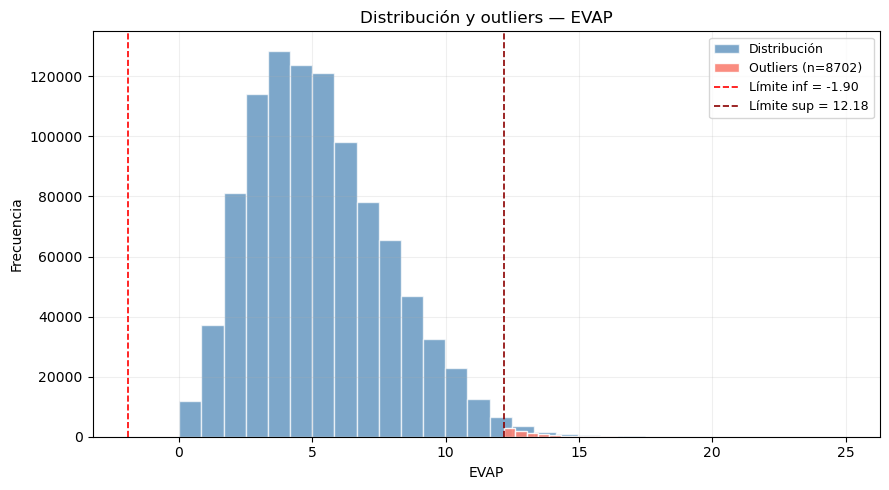

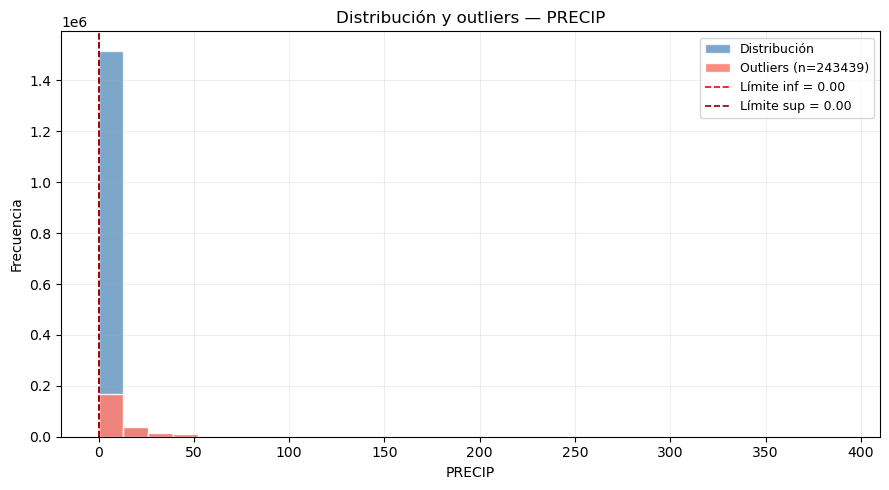

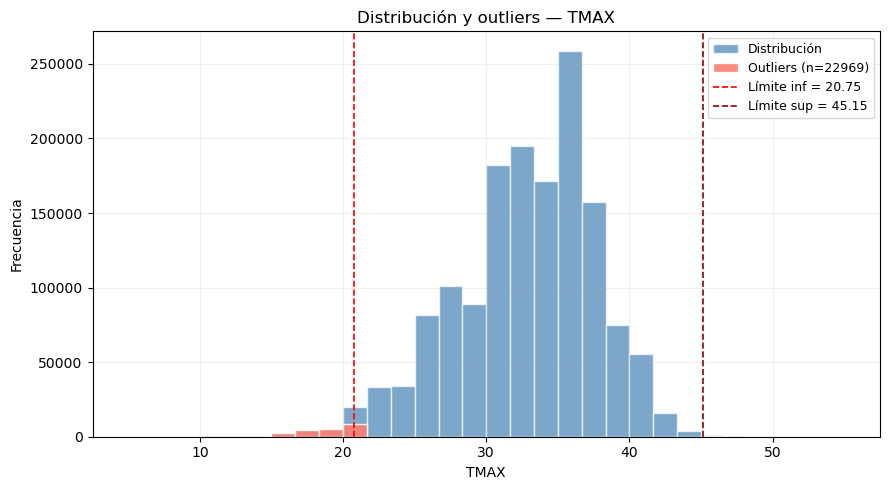

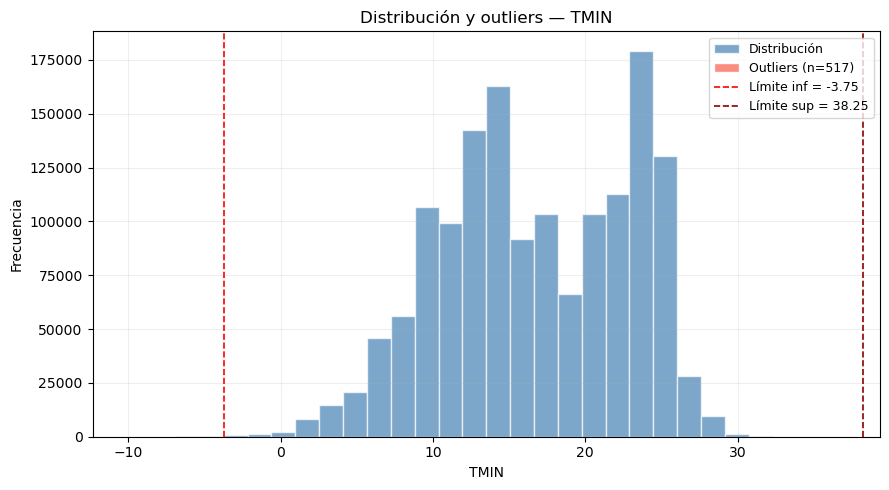

In [41]:
for var in variables_en_muestra:
    x_all = eda_df.loc[eda_df["variable"] == var, "value"].dropna()
    if x_all.empty:
        continue

    q1    = x_all.quantile(0.25)
    q3    = x_all.quantile(0.75)
    lower = q1 - 1.5 * (q3 - q1)
    upper = q3 + 1.5 * (q3 - q1)
    x_out = x_all[(x_all < lower) | (x_all > upper)]

    plt.figure(figsize=(9, 5))
    plt.hist(x_all, bins=30, color="steelblue", edgecolor="white", alpha=0.7, label="Distribución")
    if not x_out.empty:
        plt.hist(x_out, bins=30, color="salmon", edgecolor="white", alpha=0.9,
                 label=f"Outliers (n={len(x_out)})")
    plt.axvline(lower, color="red",     linestyle="--", linewidth=1.2,
                label=f"Límite inf = {lower:.2f}")
    plt.axvline(upper, color="darkred", linestyle="--", linewidth=1.2,
                label=f"Límite sup = {upper:.2f}")
    plt.xlabel(var.upper())
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución y outliers — {var.upper()}")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Interpretación

Se detectaron **275,627 registros atípicos** en total (4.3% del total de valores no nulos), distribuidos de forma muy desigual entre variables:

| Variable | Outliers | % sobre valores válidos | Tipo dominante |
|----------|----------|------------------------|----------------|
| `precip` | 243,439 | **15.3%** | Extremo alto |
| `tmax` | 22,969 | 1.5% | Extremo bajo (18,370) y alto (963) |
| `evap` | 8,702 | 0.88% | Extremo alto |
| `tmin` | 517 | 0.03% | Extremo bajo |

El elevado porcentaje de outliers en `precip` (15.3%) se explica metodológicamente: cuando el IQR es cero (la mayoría de los días no llueve), cualquier valor positivo es clasificado como outlier por el criterio IQR×1.5. Esto no implica que todos sean errores, sino que la distribución de precipitación no es apropiada para este criterio sin transformación previa.

Para `tmax`, los 22,006 outliers en extremo bajo (valores entre 5°C y 20.7°C) merecen revisión: pueden ser errores de registro o confusiones con `tmin`. El valor máximo registrado de 55°C es físicamente inverosímil para Sinaloa y debe tratarse como error.

Estos resultados orientan la estrategia de limpieza: aplicar límites físicos por variable antes del modelado, y considerar una transformación logarítmica para `precip` en el análisis de outliers.


---
## Consolidado de hallazgos principales

In [42]:
hallazgos = pd.DataFrame({
    "criterio": [
        "Análisis descriptivo", "Análisis descriptivo", "Análisis descriptivo",
        "Visualizaciones",      "Visualizaciones",      "Visualizaciones",
        "Outliers",             "Outliers"
    ],
    "hallazgo": [
        "El dataset está organizado modularmente por estación, año y variable.",
        "La cobertura temporal por estación es heterogénea.",
        "El porcentaje de faltantes varía entre particiones, variables y estaciones.",
        "PRECIP muestra asimetría positiva; TMAX y TMIN distribuciones más simétricas.",
        "La correlación TMAX–TMIN es positiva; la relación PRECIP–EVAP puede ser débil o negativa.",
        "Las series temporales muestran continuidad general con huecos identificables.",
        "Se detectaron valores atípicos en todas las variables usando el criterio IQR×1.5.",
        "Los outliers pueden ser eventos reales o errores de registro; requieren revisión contextual."
    ]
})
hallazgos

,criterio,hallazgo
0,Análisis descriptivo,El dataset está organizado modularmente por es...
1,Análisis descriptivo,La cobertura temporal por estación es heterogé...
2,Análisis descriptivo,El porcentaje de faltantes varía entre partici...
3,Visualizaciones,PRECIP muestra asimetría positiva; TMAX y TMIN...
4,Visualizaciones,La correlación TMAX–TMIN es positiva; la relac...
5,Visualizaciones,Las series temporales muestran continuidad gen...
6,Outliers,Se detectaron valores atípicos en todas las va...
7,Outliers,Los outliers pueden ser eventos reales o error...


## Conclusiones

El análisis exploratorio general permitió obtener una visión cuantitativa e integral de la estructura, cobertura y calidad del dataset hidrometeorológico organizado de Sinaloa.

**Estructura y cobertura:** el dataset comprende 19,256 particiones generadas a partir de 168 estaciones con registros entre 1908 y 2026 (hasta 118 años de historia). La cobertura temporal es heterogénea: la mediana por estación es de 25 años, con un máximo de 84 años (estación 25046, Jaina). Las 24 estaciones sin particiones en el índice requieren revisión de sus archivos crudos.

**Faltantes:** el 13.3% del total de valores son nulos (850,639 de 6,405,536 registros). La distribución es muy desigual: `precip` presenta apenas 0.8% de faltantes, `tmax` y `tmin` un 7.4% simétrico —lo que indica que fallan juntas—, y `evap` un preocupante **39.5% promedio**, con numerosas particiones al 100% de faltantes. Esta variable requerirá una estrategia de imputación diferenciada o su exclusión en estaciones sin datos suficientes.

**Estadística descriptiva:** `precip` presenta asimetría positiva severa (media 1.96 mm, mediana 0.0 mm, máximo 390.5 mm). `tmax` y `tmin` tienen distribuciones aproximadamente simétricas centradas en 32.7°C y 16.7°C respectivamente. El valor máximo de `tmax` (55°C) y el mínimo de `tmin` (-10°C) son candidatos a corrección por límites físicos.

**Relaciones entre variables:** TMAX y EVAP muestran la correlación más fuerte (r=0.572), seguida de TMAX–TMIN (r=0.527). PRECIP y EVAP no presentan relación lineal apreciable (r=-0.011). Estas correlaciones justifican el uso de modelos multivariantes para la imputación.

**Outliers:** se detectaron 275,627 registros atípicos (4.3%). El 88% corresponde a `precip`, donde el criterio IQR×1.5 clasifica todo valor positivo como outlier dado que el IQR es cero. Esto requiere una transformación o un criterio alternativo antes de la limpieza. Los outliers de `tmax` en extremo bajo (22,006 registros entre 5°C y 20.7°C) son la señal de alerta más relevante para la calidad del dato.

La información obtenida confirma que la base está en condiciones adecuadas para avanzar hacia la limpieza específica por variable, la definición de límites físicos y la implementación de los modelos de imputación generativa.


## Entregable de la actividad

Este notebook constituye el entregable correspondiente a la actividad **2.4 Perfilamiento EDA general** del backlog del proyecto, al incluir:

**Criterio 1 — Análisis descriptivo de variables numéricas y categóricas:**
- Estadísticas completas: media, mediana, moda, std, percentiles p5/p10/p25/p75/p90/p95, mínimo y máximo
- Frecuencias de variables categóricas: variable climática, estación y año

**Criterio 2 — Visualizaciones exploratorias:**
- Histogramas con líneas de media y mediana
- Boxplots con identificación visual de outliers
- Diagramas de dispersión entre pares de variables con correlación de Pearson
- Gráficos de barras de frecuencias categóricas (variable, estación, año)
- Series temporales de ejemplo

**Criterio 3 — Identificación y análisis de valores atípicos:**
- Detección por criterio IQR×1.5 con límites calculados por variable
- Registro detallado de outliers (estación, fecha, valor, tipo)
- Documentación de posibles causas e impacto en el análisis
- Visualización de outliers sobre la distribución de cada variable